![Ironhack logo](https://user-images.githubusercontent.com/23629340/40541063-a07a0a8a-601a-11e8-91b5-2f13e4e6b441.png)

# 01 | Exploratory Data Analysis

*Project 1 — SQL: From Data to Insight*

**Team:**
**Dataset:**

---

Understanding your data before you design anything. You cannot decide which tables you need until you know which columns repeat, which are broken, and which identify a row.

> **Done when:** you can name the 3+ tables you are going to build, you have written down at least 2 research questions, and you know every data-quality problem notebook 02 will have to fix.

The sections below are a suggested route, not a form to fill in. Add sections, drop them, reorder them — what is graded is the analysis, not whether you kept the scaffold.

---
## 0. Setup

In [1]:
%pip install openpyxl
%pip show openpyxl
%pip install python-dotenv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Name: openpyxl
Version: 3.1.5
Summary: A Python library to read/write Excel 2010 xlsx/xlsm files
Home-page: https://openpyxl.readthedocs.io
Author: See AUTHORS
Author-email: charlie.clark@clark-consulting.eu
License: MIT
Location: c:\Users\rkham\AppData\Local\Programs\Python\Python311\Lib\site-packages
Requires: et-xmlfile
Required-by: 
Note: you may need to restart the kernel to use updated packages.




[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
sys.path.append("..")          # so `src` is importable from inside notebooks/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.functions import *

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

---
## 1. Load the raw data

Run `python download_data.py <payments|airbnb|retail>` from the repo root first. Your files land in `data/raw/`, which is gitignored.

The data for this project came from https://cpds-data.org/data/

In [3]:
# Puting all private info in extra file, so its not available for public and than retrieving it
from dotenv import load_dotenv
import os

load_dotenv()

data_path = os.getenv("DATA_PATH")

if data_path is None:
    raise ValueError("DATA_PATH is not set. Create a .env file first.")

In [4]:
raw_data = data_path
print(data_path)

C:\Users\rkham\OneDrive\Desktop\ironhack_project\project-1-eda-sql\data\raw\rawdata.xlsx


---
## 2. First look

Shape, column types, a handful of rows. What is one row of this data?

In [5]:
df = pd.read_excel(raw_data)


In [6]:
df.shape

(1902, 341)

In [7]:
df.head()

,year,country,countryn,iso,iso3n,cpds1,poco,eu,emu,gov_right1,gov_cent1,gov_left1,gov_party,gov_new,gov_gap,gov_chan,gov_right2,gov_cent2,gov_left2,gov_right3,gov_cent3,gov_left3,gov_sup,gov_type,year_01,country_01,elect,vturn,social1,social2,social3,social4,social5,social6,social7,social8,social9,leftsoc1,leftsoc2,leftsoc3,leftsoc4,leftsoc5,comm1,comm2,comm3,comm4,postcom1,postcom2,agrarian1,agrarian2,...,survivor_pmp,incapben_pmp,health_pmp,family_pmp,almp_pmp,unemp_pmp,housing_pmp,othsocx_pmp,year_10,country_10,educexp_gov,educexp_gov_ipol,educexp_public,educexp_public_ipol,educexp_private,educexp_private_ipol,educatt_minimal,educatt_minimal_ipol,educatt_tertiary,educatt_tertiary_ipol,year_11,country_11,fallow_pmp,mpleave_pmp,othfam_c_pmp,childcare_pmp,homehelp_pmp,othfam_k_pmp,servadmi_pmp,training_pmp,jobrot_pmp,incent_pmp,disabled_pmp,jobcrea_pmp,startup_pmp,compen_pmp,earretir_pmp,year_12,country_12,emprot_reg,emprot_temp,prefisc_gini,pretran_gini,postfisc_gini,pop,pop15_64,pop65,elderly,year_13,country_13
0,1960,Australia,1,AUS,36,1,0.0,0.0,0.0,100.0,0.0,0.0,1.0,0.0,0.0,0.0,100.0,0.0,0.0,63.10,0.0,0.0,63.10,2.0,1960,Australia,NaT,95.5,42.8,7.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.3,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1960,Australia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1960,Australia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1960,Australia,NaN,NaN,NaN,NaN,NaN,10329.8,6355.9,889.8,8.613913,1960,Australia
1,1961,Australia,1,AUS,36,1,0.0,0.0,0.0,100.0,0.0,0.0,1.0,0.0,0.0,1.0,100.0,0.0,0.0,62.80,0.0,0.0,62.80,2.0,1961,Australia,1961-12-09,95.3,47.9,7.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.5,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1961,Australia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1961,Australia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1961,Australia,NaN,NaN,NaN,NaN,NaN,10534.4,6489.2,909.8,8.636467,1961,Australia
2,1962,Australia,1,AUS,36,1,0.0,0.0,0.0,100.0,0.0,0.0,1.0,0.0,0.0,0.0,100.0,0.0,0.0,50.80,0.0,0.0,50.80,2.0,1962,Australia,NaT,95.3,47.9,7.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.5,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1962,Australia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1962,Australia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1962,Australia,NaN,NaN,NaN,NaN,NaN,10733.3,6633.4,929.1,8.656238,1962,Australia
3,1963,Australia,1,AUS,36,1,0.0,0.0,0.0,100.0,0.0,0.0,1.0,0.0,0.0,1.0,100.0,0.0,0.0,51.14,0.0,0.0,51.14,2.0,1963,Australia,1963-11-30,95.7,45.5,7.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.9,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1963,Australia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1963,Australia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1963,Australia,NaN,NaN,NaN,NaN,NaN,10936.7,6774.2,948.9,8.676292,1963,Australia
4,1964,Australia,1,AUS,36,1,0.0,0.0,0.0,100.0,0.0,0.0,1.0,0.0,0.0,0.0,100.0,0.0,0.0,59.00,0.0,0.0,59.00,2.0,1964,Australia,NaT,95.7,45.5,7.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.9,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1964,Australia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1964,Australia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1964,Australia,NaN,NaN,NaN,NaN,NaN,11158.5,6921.9,964.2,8.640946,1964,Australia


---
## 3. Data quality

Missing values, duplicates, numbers stored as text, dates stored as strings. Write down what you find — this is the to-do list for notebook 02.

In [8]:
#General info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1902 entries, 0 to 1901
Columns: 341 entries, year to country_13
dtypes: datetime64[us](1), float64(307), int64(17), object(1), str(15)
memory usage: 4.9+ MB


In [9]:
#Missing values
missing_values = df.isna().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

lrid          1857
lsec          1857
lmin          1857
lexe          1857
ljud          1857
              ... 
sconserv12       6
eu               6
right6           6
poco             6
pop              2
Length: 309, dtype: int64

In [10]:
#Duplicated values
df.duplicated().sum()

np.int64(0)

In [11]:
#check if the most important columns for our research are unique
df.duplicated(subset=["country", "year"]).sum()

np.int64(0)

In [12]:
#Data types
df.dtypes.value_counts()

float64           307
int64              17
str                15
datetime64[us]      1
object              1
Name: count, dtype: int64

In [13]:
#Count number of distinct elements in country column
df["country"].nunique()

36

In [14]:
#Check the counties spelling
df["country"].unique()

<StringArray>
[     'Australia',        'Austria',        'Belgium',       'Bulgaria',
         'Canada',        'Croatia',         'Cyprus', 'Czech Republic',
        'Denmark',        'Estonia',        'Finland',         'France',
        'Germany',         'Greece',        'Hungary',        'Iceland',
        'Ireland',          'Italy',          'Japan',         'Latvia',
      'Lithuania',     'Luxembourg',          'Malta',    'Netherlands',
    'New Zealand',         'Norway',         'Poland',       'Portugal',
        'Romania',       'Slovakia',       'Slovenia',          'Spain',
         'Sweden',    'Switzerland', 'United Kingdom',            'USA']
Length: 36, dtype: str

In [15]:
#Check if the year range is what is announced in data description
df["year"].min(), df["year"].max()

(np.int64(1960), np.int64(2023))

In [16]:
#Check if all countries have data for all years
df["year"].value_counts().sort_index()

year
1960    21
1961    21
1962    21
1963    21
1964    21
        ..
2019    36
2020    36
2021    36
2022    36
2023    36
Name: count, Length: 64, dtype: int64

In [17]:
# Check if countries have country_id to use it as primary key for later. if not, then find the best candidate for this
import re

country_id_columns = [
    col for col in df.columns
    if re.search(r"country|id", str(col), re.IGNORECASE)
]

print(country_id_columns) #there is a countryn column wich we possibly could use as 
print(len(df["countryn"].unique()))#number of country looks like a good pretendent


['country', 'countryn', 'country_01', 'country_02', 'country_03', 'country_04', 'lrid', 'country_05', 'country_06', 'country_07', 'country_08', 'country_09', 'country_10', 'country_11', 'country_12', 'country_13']
36


Check what columns can be used as primary keys

In [18]:
#check for primary key column for country and rename the column to country_id!!
df[["country","countryn"]]

,country,countryn
0,Australia,1
1,Australia,1
2,Australia,1
3,Australia,1
4,Australia,1
...,...,...
1897,USA,36
1898,USA,36
1899,USA,36
1900,USA,36


---
## 4. Distributions

The numeric columns you care about, and the outliers you will have to decide about.

In [19]:
numeric_columns = [
    "realgdpgr",
    "unemp",
    "inflation"
]

df[numeric_columns].describe()

,realgdpgr,unemp,inflation
count,1828.000000,1834.000000,1811.000000
mean,2.820562,6.464583,5.426491
std,3.439066,4.318762,15.318944
min,-21.374046,0.000000,-4.447547
25%,1.374486,3.500000,1.648223
50%,2.929554,5.800000,3.041363
75%,4.668350,8.500000,6.152574
max,22.344065,27.800000,552.083514


<Axes: >

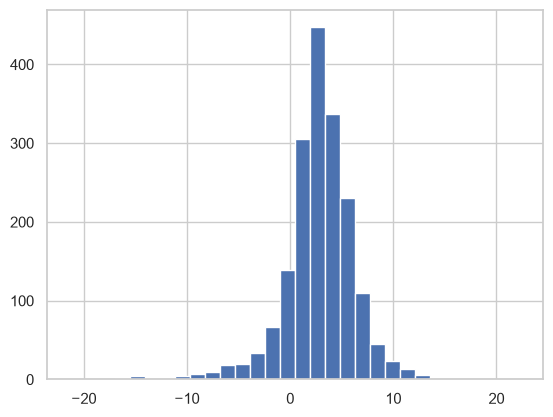

In [20]:
df["realgdpgr"].hist(bins=30)
#gdp data have a normal distribution slightly moved to the right

<Axes: >

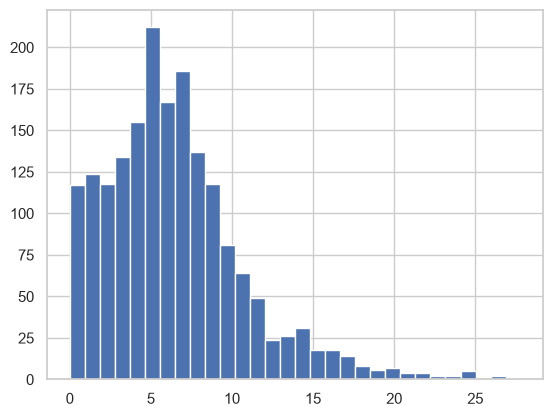

In [21]:
df["unemp"].hist(bins=30)
#A histogram is right skewed 
#Right Skewed Distribution: Mode < Median < Mean

(0.0, 40.0)

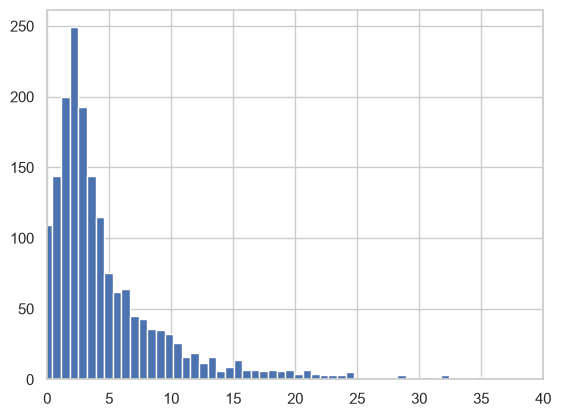

In [22]:
df["inflation"].hist(bins=800)
plt.xlim(0, 40)

# histogram for inflation data shows a strongly right-skewed distribution
# most inflation observations appear concentrated roughly around 0–10%, while a small number of observations extend much farther to the right.

## GDP

GDP distribution looks normal, so no further investigation required at this stage

<Axes: >

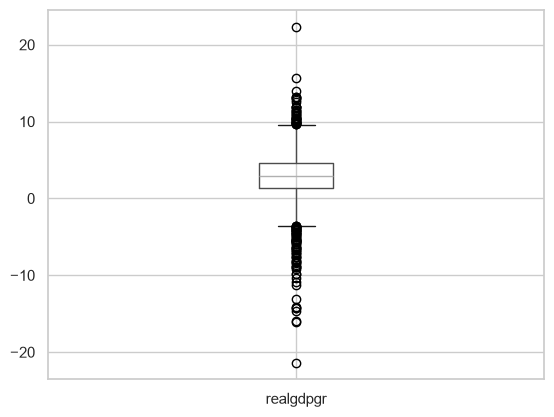

In [23]:
df.boxplot(column="realgdpgr")

### Unemployment check in detail:

<Axes: >

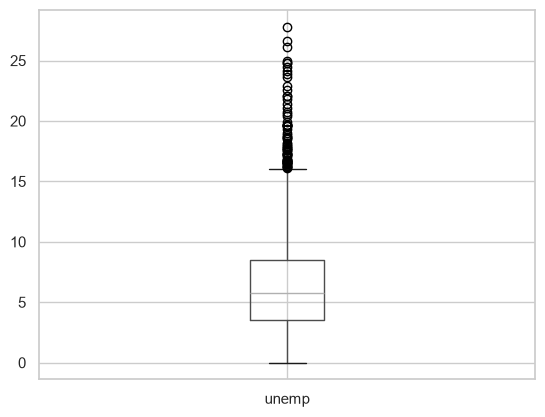

In [24]:
df.boxplot(column="unemp")

In [25]:
df["unemp"].describe()

count    1834.000000
mean        6.464583
std         4.318762
min         0.000000
25%         3.500000
50%         5.800000
75%         8.500000
max        27.800000
Name: unemp, dtype: float64

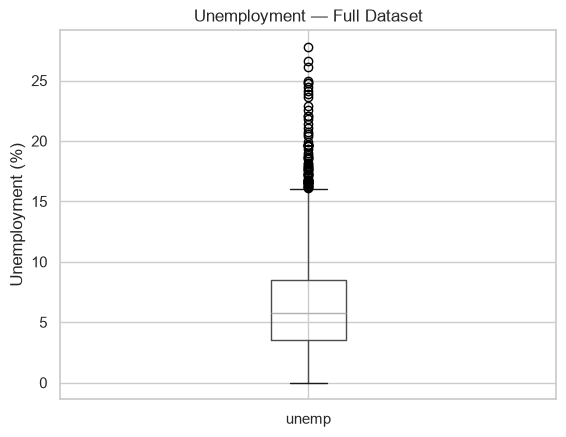

In [26]:
df.boxplot(column="unemp")

plt.ylabel("Unemployment (%)")
plt.title("Unemployment — Full Dataset")
plt.show()

In [27]:
df.nlargest(10, "unemp")[
    ["country", "year", "unemp"]
]

,country,year,unemp
737,Greece,2013,27.8
738,Greece,2014,26.6
1635,Spain,2013,26.1
739,Greece,2015,25.0
736,Greece,2012,24.8
1634,Spain,2012,24.8
1636,Spain,2014,24.5
1616,Spain,1994,24.1
740,Greece,2016,23.9
203,Bulgaria,2001,23.6


In [28]:
df.nsmallest(10, "unemp")[
    ["country", "year", "unemp"]
]

,country,year,unemp
782,Iceland,1960,0.0
785,Iceland,1963,0.0
1101,Luxembourg,1960,0.0
1102,Luxembourg,1961,0.0
1103,Luxembourg,1962,0.0
1104,Luxembourg,1963,0.0
1105,Luxembourg,1964,0.0
1106,Luxembourg,1965,0.0
1107,Luxembourg,1966,0.0
1108,Luxembourg,1967,0.0


In [29]:
# distribution/outlier analysis on the filtered dataset rather than the full historical dataset
df_period = df[df["year"].between(2000, 2019)].copy()

In [30]:
df_period["unemp"].describe()

count    720.000000
mean       7.986528
std        4.284364
min        2.000000
25%        5.000000
50%        6.900000
75%        9.300000
max       27.800000
Name: unemp, dtype: float64

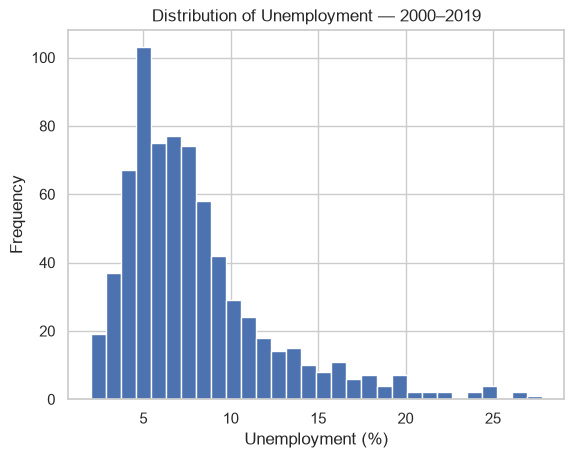

In [31]:
df_period["unemp"].hist(bins=30)

plt.xlabel("Unemployment (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Unemployment — 2000–2019")
plt.show()

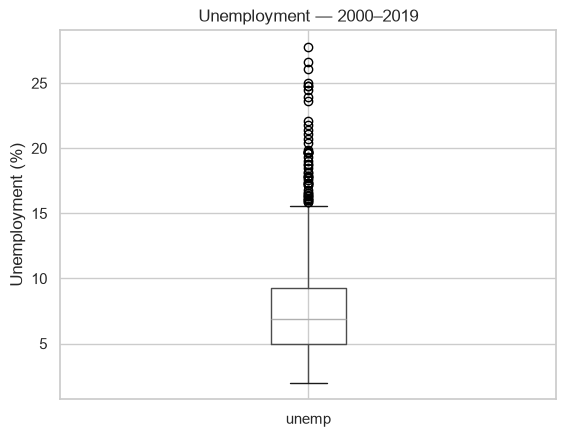

In [32]:
df_period.boxplot(column="unemp")

plt.ylabel("Unemployment (%)")
plt.title("Unemployment — 2000–2019")
plt.show()

In [33]:
df_period.nlargest(10, "unemp")[
    ["country", "year", "unemp"]
]

,country,year,unemp
737,Greece,2013,27.8
738,Greece,2014,26.6
1635,Spain,2013,26.1
739,Greece,2015,25.0
736,Greece,2012,24.8
1634,Spain,2012,24.8
1636,Spain,2014,24.5
740,Greece,2016,23.9
203,Bulgaria,2001,23.6
1637,Spain,2015,22.1


### Inflation check in detail:

<Axes: >

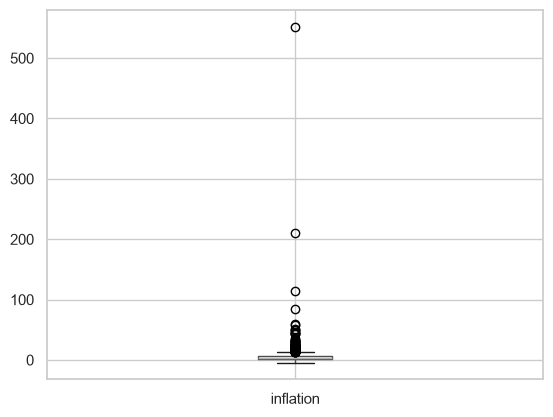

In [34]:
df.boxplot(column="inflation")

In [35]:
q1 = df["inflation"].quantile(0.25)
q3 = df["inflation"].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 1.6482231165748549
Q3: 6.15257447973025
IQR: 4.504351363155395
Lower bound: -5.108303928158238
Upper bound: 12.909101524463342


In [36]:
inflation_outliers = df[
    (df["inflation"] < lower_bound) |
    (df["inflation"] > upper_bound)
]

inflation_outliers[["country", "year", "inflation"]]

,country,year,inflation
14,Australia,1974,15.416667
15,Australia,1975,15.162455
16,Australia,1976,13.322884
200,Bulgaria,1998,18.610422
224,Bulgaria,2022,12.991766
...,...,...,...
1790,United Kingdom,1976,16.559525
1791,United Kingdom,1977,15.840272
1793,United Kingdom,1979,13.421286
1794,United Kingdom,1980,17.965925


In [37]:
df.nlargest(10, "inflation")[
    ["country", "year", "inflation"]
]

,country,year,inflation
1565,Slovenia,1990,552.083514
1567,Slovenia,1992,209.933757
1566,Slovenia,1991,114.832925
805,Iceland,1983,83.950046
1505,Romania,1998,59.036145
802,Iceland,1980,58.528428
803,Iceland,1981,51.793249
804,Iceland,1982,50.243224
797,Iceland,1975,49.361340
1507,Romania,2000,45.833333


In [38]:
df_2000_2019 = df[
    df["year"].between(2000, 2019)
]

df_2000_2019.nlargest(10, "inflation")[
    ["country", "year", "inflation"]
]

,country,year,inflation
1507,Romania,2000,45.833333
1508,Romania,2001,34.642857
1509,Romania,2002,22.281167
1510,Romania,2003,15.401302
1053,Latvia,2008,15.170670
830,Iceland,2008,12.694402
1541,Slovakia,2000,12.035777
831,Iceland,2009,12.003117
210,Bulgaria,2008,11.980440
1511,Romania,2004,11.842105


Text(0.5, 1.0, 'Inflation Distribution, 2000–2019')

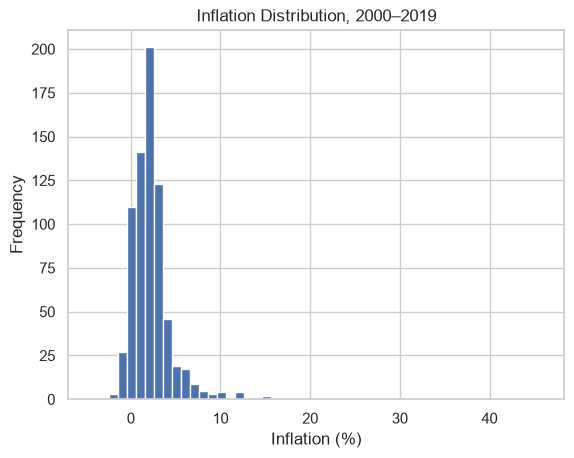

In [39]:
df_period["inflation"].hist(bins=50)
plt.xlabel("Inflation (%)")
plt.ylabel("Frequency")
plt.title("Inflation Distribution, 2000–2019")

Text(0.5, 1.0, 'Inflation, 2000–2019')

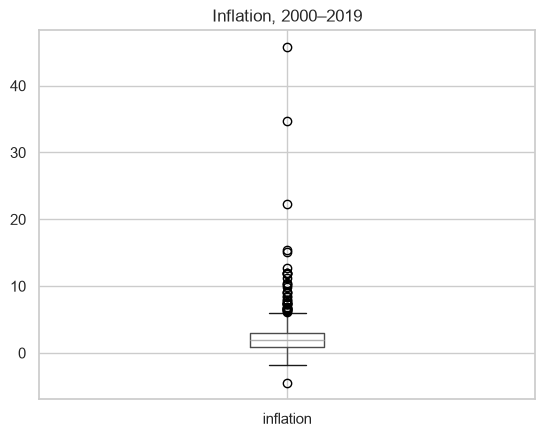

In [40]:
df_period.boxplot(column="inflation")
plt.title("Inflation, 2000–2019")

In [41]:
df_period.nlargest(10, "inflation")[
    ["country", "year", "inflation"]
]

,country,year,inflation
1507,Romania,2000,45.833333
1508,Romania,2001,34.642857
1509,Romania,2002,22.281167
1510,Romania,2003,15.401302
1053,Latvia,2008,15.170670
830,Iceland,2008,12.694402
1541,Slovakia,2000,12.035777
831,Iceland,2009,12.003117
210,Bulgaria,2008,11.980440
1511,Romania,2004,11.842105


In [42]:
df_period[
    (df_period["country"] == "Romania") &
    (df_period["year"].between(1999, 2002))
][["country", "year", "inflation"]]

,country,year,inflation
1507,Romania,2000,45.833333
1508,Romania,2001,34.642857
1509,Romania,2002,22.281167


The inflation variable is strongly right-skewed. Most observations between 2000 and 2019 are concentrated at relatively low inflation rates, while several country-year observations show substantially higher inflation. The boxplot identifies these observations as statistical outliers according to the IQR rule, but they are not necessarily data errors and should not be removed without further investigation.

--
After verifying the data with the world data bank, we can conclude that 45.8% inflation in romania is an accurate value(even though its unusual, so we can keep it), since previos peack of inflation in 1993 was even bigger
https://data.worldbank.org/indicator/FP.CPI.TOTL.ZG?locations=RO

---
## 5. Categorical columns

**This is the section that feeds tomorrow.** A column with few distinct values repeated over many rows is a lookup table waiting to happen. Find them.

In [43]:
categorical_columns = df.select_dtypes(include=["object"]).columns

categorical_columns

C:\Users\rkham\AppData\Local\Temp\ipykernel_29352\566229202.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object"]).columns


Index(['country', 'iso', 'country_01', 'country_02', 'country_03',
       'country_04', 'country_05', 'country_06', 'kaopen', 'country_07',
       'country_08', 'country_09', 'country_10', 'country_11', 'country_12',
       'country_13'],
      dtype='str')

In [44]:
df[categorical_columns].nunique().sort_values()

kaopen        27
country       36
country_01    36
iso           36
country_03    36
country_04    36
country_05    36
country_02    36
country_06    36
country_07    36
country_08    36
country_09    36
country_10    36
country_11    36
country_12    36
country_13    36
dtype: int64

In [45]:
df["gov_party"].value_counts(dropna=False)

gov_party
1.0    801
3.0    334
2.0    325
5.0    234
4.0    195
NaN     13
Name: count, dtype: int64

In [46]:
df["country"].value_counts(dropna=False)

country
Australia         64
Austria           64
Belgium           64
Canada            64
Denmark           64
Finland           64
France            64
Germany           64
Greece            64
Iceland           64
Ireland           64
Italy             64
Japan             64
Luxembourg        64
Netherlands       64
New Zealand       64
Norway            64
Sweden            64
Switzerland       64
United Kingdom    64
USA               64
Malta             58
Portugal          49
Cyprus            48
Spain             47
Bulgaria          34
Czech Republic    34
Hungary           34
Romania           34
Slovakia          34
Slovenia          34
Poland            33
Estonia           32
Lithuania         32
Latvia            31
Croatia           24
Name: count, dtype: int64

In [47]:
df["gov_party"].nunique()

5

### Check up for extra columns:

Since the main focus of interest should be impact of country politics on the economy we are also going to check political data. Govermental parties are identified as numbers from 1 to 5
### Government Party Composition

### `gov_party`

Cabinet composition based on the **Schmidt Index**:

| Value | Description | Share of Left-Wing Parties |
|------:|-------------|----------------------------|
| 1 | Hegemony of right-wing and center parties | `gov_left1 = 0` |
| 2 | Dominance of right-wing and center parties | `0 < gov_left1 <= 33.33` |
| 3 | Balance of power between left and right | `33.33 < gov_left1 < 66.67` |
| 4 | Dominance of social-democratic and other left parties | `66.67 <= gov_left1 < 100` |
| 5 | Hegemony of social-democratic and other left parties | `gov_left = 100` |

### Coverage

- **Period covered:** 1960–2023

### Missing Values

Missing observations occur for:

- Bulgaria: 1993–1994
- Italy: 2012
- Romania: 2015–2016

These correspond to **full technocratic governments** or **partisan caretaker governments**.

### Source

Own calculations according to **Schmidt (1992)**.

In [48]:
df["gov_party"].nunique()

5

In [49]:
df["gov_party"].value_counts(dropna=False)

gov_party
1.0    801
3.0    334
2.0    325
5.0    234
4.0    195
NaN     13
Name: count, dtype: int64

In [50]:
df["gov_party"].unique()

array([ 1.,  2.,  5.,  4.,  3., nan])

In [51]:
# for time period od interest
df_period["gov_party"].value_counts(dropna=False)


gov_party
1.0    294
3.0    131
2.0    129
4.0     89
5.0     77
Name: count, dtype: int64

In [52]:
df_period["gov_party"].value_counts(
    normalize=True,
    dropna=False
) * 100

gov_party
1.0    40.833333
3.0    18.194444
2.0    17.916667
4.0    12.361111
5.0    10.694444
Name: proportion, dtype: float64

Chcek related to goverment_party columns:

In [53]:
df.columns[
    df.columns.str.contains(
        "gov.*left|gov.*cent|gov.*right|gov.*party",
        case=False,
        regex=True
    )
].tolist()

['gov_right1',
 'gov_cent1',
 'gov_left1',
 'gov_party',
 'gov_right2',
 'gov_cent2',
 'gov_left2',
 'gov_right3',
 'gov_cent3',
 'gov_left3']

In [54]:
df[
    ["country", "year", "gov_party",
     "gov_left1", "gov_cent1", "gov_right1"]
].head(20)

,country,year,gov_party,gov_left1,gov_cent1,gov_right1
0,Australia,1960,1.0,0.00,0.0,100.00
1,Australia,1961,1.0,0.00,0.0,100.00
2,Australia,1962,1.0,0.00,0.0,100.00
3,Australia,1963,1.0,0.00,0.0,100.00
4,Australia,1964,1.0,0.00,0.0,100.00
5,Australia,1965,1.0,0.00,0.0,100.00
6,Australia,1966,1.0,0.00,0.0,100.00
7,Australia,1967,1.0,0.00,0.0,100.00
8,Australia,1968,1.0,0.00,0.0,100.00
9,Australia,1969,1.0,0.00,0.0,100.00


In [55]:
df_period[
    ["country", "year", "gov_party",
     "gov_left1", "gov_cent1", "gov_right1"]
].head(20)

,country,year,gov_party,gov_left1,gov_cent1,gov_right1
40,Australia,2000,1.0,0.00,0.0,100.00
41,Australia,2001,1.0,0.00,0.0,100.00
42,Australia,2002,1.0,0.00,0.0,100.00
43,Australia,2003,1.0,0.00,0.0,100.00
44,Australia,2004,1.0,0.00,0.0,100.00
45,Australia,2005,1.0,0.00,0.0,100.00
46,Australia,2006,1.0,0.00,0.0,100.00
47,Australia,2007,2.0,7.95,0.0,92.05
48,Australia,2008,5.0,100.00,0.0,0.00
49,Australia,2009,5.0,100.00,0.0,0.00


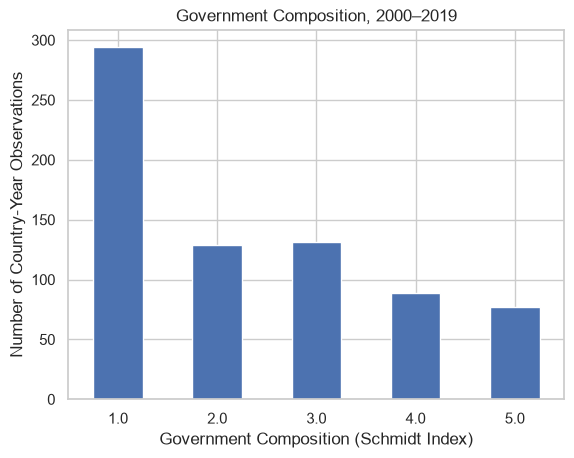

In [56]:
df_period["gov_party"].value_counts().sort_index().plot(
    kind="bar"
)

plt.xlabel("Government Composition (Schmidt Index)")
plt.ylabel("Number of Country-Year Observations")
plt.title("Government Composition, 2000–2019")
plt.xticks(rotation=0)
plt.show()

In [57]:
df_period[df_period["gov_party"].isna()][
    ["country", "year", "gov_left1", "gov_cent1", "gov_right1"]
]

,country,year,gov_left1,gov_cent1,gov_right1


In [58]:
political_columns = [
    "gov_left1",
    "gov_cent1",
    "gov_right1"
]

df[political_columns].describe()

,gov_left1,gov_cent1,gov_right1
count,1890.000000,1890.000000,1890.000000
mean,31.792513,22.997484,40.040675
std,36.090223,31.039938,37.349139
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,20.020000,3.570000,36.855000
75%,54.047500,42.710000,72.277500
max,100.000000,100.000000,100.000000


In [59]:
df[political_columns].isna().sum()


gov_left1     12
gov_cent1     12
gov_right1    12
dtype: int64

In [60]:
df_period[political_columns].describe()

,gov_left1,gov_cent1,gov_right1
count,720.000000,720.000000,720.000000
mean,31.358977,20.347980,42.487522
std,35.085992,29.684613,36.000020
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,20.000000,3.215000,42.330000
75%,53.357500,33.330000,72.459318
max,100.000000,100.000000,100.000000


In [61]:
#Check if all values are in percentual range:
for column in political_columns:
    invalid_values = df[
        (df[column] < 0) | (df[column] > 100)
    ]

    print(column, len(invalid_values))

gov_left1 1
gov_cent1 0
gov_right1 0


In [62]:
df[
    (df["gov_left1"] < 0) |
    (df["gov_left1"] > 100)
][
    ["country", "year", "gov_party",
     "gov_left1", "gov_cent1", "gov_right1"]
]

,country,year,gov_party,gov_left1,gov_cent1,gov_right1
1180,Malta,1981,NaN,100.0,0.0,0.0


In [63]:
#Is this going to impact our time period?
df_period[
    (df_period["gov_left1"] < 0) |
    (df_period["gov_left1"] > 100)
][
    ["country", "year", "gov_party",
     "gov_left1", "gov_cent1", "gov_right1"]
]

,country,year,gov_party,gov_left1,gov_cent1,gov_right1


**Government composition range check**

The government composition variables were checked for values outside the expected
0–100% range. One out-of-range value was identified in `gov_left1` in the full
historical dataset. However, this observation falls outside the selected analysis
period (2000–2019) and therefore does not affect the final analytical dataset.

No out-of-range values were found for the selected period.

In [64]:
government_total = (
    df_period["gov_left1"]
    + df_period["gov_cent1"]
    + df_period["gov_right1"]
)

government_total.describe()

count    720.000000
mean      94.194478
std       12.623655
min        0.000000
25%       94.135000
50%      100.000000
75%      100.000000
max      100.200000
dtype: float64

In [65]:
government_total.value_counts().sort_index().head(20)

0.000000     2
30.930000    1
33.420000    1
34.885845    1
37.720000    1
40.310000    1
40.610000    1
43.980000    1
45.800000    1
49.130000    1
52.694064    1
55.130000    1
55.452055    1
55.560000    1
55.870000    1
56.290000    1
57.130000    1
57.890000    1
58.170000    1
58.360000    1
Name: count, dtype: int64

In [66]:
print("Below 99%:", (government_total < 99).sum())
print("99–101%:", government_total.between(99, 101).sum())
print("Above 101%:", (government_total > 101).sum())

Below 99%: 214
99–101%: 506
Above 101%: 0


In [67]:
df_period.assign(
    government_total=government_total
).nsmallest(10, "government_total")[
    [
        "country",
        "year",
        "gov_party",
        "gov_left1",
        "gov_cent1",
        "gov_right1",
        "government_total"
    ]
]

,country,year,gov_party,gov_left1,gov_cent1,gov_right1,government_total
962,Italy,2012,1.0,0.000000,0.00,0.000000,0.000000
1523,Romania,2016,1.0,0.000000,0.00,0.000000,0.000000
381,Czech Republic,2009,2.0,5.800000,7.73,17.400000,30.930000
350,Cyprus,2012,4.0,33.420000,0.00,0.000000,33.420000
216,Bulgaria,2014,3.0,13.964992,0.00,20.920852,34.885845
215,Bulgaria,2013,3.0,13.320000,0.00,24.400000,37.720000
385,Czech Republic,2013,1.0,0.000000,3.20,37.110000,40.310000
123,Austria,2019,1.0,0.000000,21.29,19.320000,40.610000
382,Czech Republic,2010,1.0,0.000000,0.00,43.980000,43.980000
357,Cyprus,2019,1.0,0.000000,0.00,45.800000,45.800000


---
## 6. Research questions

At least two, written here. Specific, answerable with this data, and with an answer you could be wrong about. For each one, say what you expect and why.

1. GDP growth and government composition
Research question:
How does average real GDP growth differ across government political compositions between 2000 and 2019?
Expectation:
I expect to observe some differences in average GDP growth between government composition categories, although I do not expect political composition alone to explain these differences because economic growth is influenced by many other factors.
2. Unemployment and government composition
Research question:
How does the unemployment rate differ across government political compositions between 2000 and 2019?
Expectation:
I expect unemployment rates to vary across government composition categories. However, I expect substantial variation within each category because unemployment is also influenced by country-specific conditions and broader economic cycles.
3. Inflation — optional but useful
Research question:
How does inflation differ across government political compositions between 2000 and 2019?
Expectation:
I expect inflation to show differences across government composition categories, but I also expect considerable variation between countries and years.
These work well because you could genuinely be wrong. For example, your SQL analysis might show virtually no meaningful difference in average GDP growth between the categories. That's still a valid result.

---
## 7. Into notebook 02

The tables you are going to build, and the problems you have to fix first.

Tables to build
1. countries — lookup table
- country_id — primary key
- country_name
- iso_code
2. government_types — lookup table
- government_type_id — primary key
- government_type
3. country_year — main analytical table
- observation_id — primary key
- country_id — foreign key → countries
- government_type_id — foreign key → government_types
- year
- left_percentage
- centre_percentage
- right_percentage
- gdp_growth
- unemployment
- inflation

Before loading the data into SQLite, I need to:
- select only the columns required for the analysis;
- filter the dataset to the selected period, 2000-2019;
- handle missing values in the selected political and economic variables;
- verify and correct data types where necessary;
- check duplicate country-year observations;
- check categorical values for inconsistent labels;
- investigate extreme values in GDP growth, unemployment and inflation before deciding whether they should be retained;
- transform repeated country and government-composition values into lookup tables;
- create primary and foreign keys for the relational database.

## Additional improvemets for data security
-added .env file where i store all the paths and keys so they are not available to public

## Info from the codebook for data:
https://cpds-data.org/wp-content/uploads/2025/09/codebook_cpds.pdf
## General Variables

| Variable | Description |
|----------|-------------|
| `year` | Year of observation |
| `country` | Country name |
| `countryn` | Country code number |

### Notes

- `year_1`, ..., `year_12` are auxiliary variables identical to `year`.
- `country_1`, ..., `country_12` are auxiliary variables identical to `country`.

### Country Codes

| Code | Country | Code | Country |
|------|---------|------|---------|
| 1 | Australia | 19 | Japan |
| 2 | Austria | 20 | Latvia |
| 3 | Belgium | 21 | Lithuania |
| 4 | Bulgaria | 22 | Luxembourg |
| 5 | Canada | 23 | Malta |
| 6 | Croatia | 24 | Netherlands |
| 7 | Cyprus (Greek part) | 25 | New Zealand |
| 8 | Czech Republic | 26 | Norway |
| 9 | Denmark | 27 | Poland |
| 10 | Estonia | 28 | Portugal |
| 11 | Finland | 29 | Romania |
| 12 | France | 30 | Slovakia |
| 13 | Germany | 31 | Slovenia |
| 14 | Greece | 32 | Spain |
| 15 | Hungary | 33 | Sweden |
| 16 | Iceland | 34 | Switzerland |
| 17 | Ireland | 35 | United Kingdom |
| 18 | Italy | 36 | USA |

### Selection of Government Composition Variables

The CPDS provides several measures of government composition and political
power. This analysis uses `gov_left1`, `gov_cent1`, and `gov_right1`, which
measure the percentage of cabinet posts held by left, centre, and right
parties, weighted by the number of days in office during each year.

These variables were selected because the main categorical variable,
`gov_party` (Schmidt Index), is based on cabinet composition and specifically
uses `gov_left1` for its classification.

The alternative `gov_*2` and `gov_*3` variables measure parliamentary
strength/support of governing parties and are outside the scope of this
analysis.

## Check where this belongs????


In [ ]:
# distribution/outlier analysis on the filtered dataset rather than the full historical dataset
df_period = df[df["year"].between(2000, 2019)].copy()

In [ ]:
df_period["inflation"].hist(bins=50)
plt.xlabel("Inflation (%)")
plt.ylabel("Frequency")
plt.title("Inflation Distribution, 2000–2019")

In [ ]:
df_period.boxplot(column="inflation")
plt.title("Inflation, 2000–2019")

In [ ]:
df_period.nlargest(10, "inflation")[
    ["country", "year", "inflation"]
]

In [ ]:
df_period[
    (df_period["country"] == "Romania") &
    (df_period["year"].between(1999, 2002))
][["country", "year", "inflation"]]

The inflation variable is strongly right-skewed. Most observations between 2000 and 2019 are concentrated at relatively low inflation rates, while several country-year observations show substantially higher inflation. The boxplot identifies these observations as statistical outliers according to the IQR rule, but they are not necessarily data errors and should not be removed without further investigation.

--
After verifying the data with the world data bank, we can conclude that 45.8% inflation in romania is an accurate value(even though its unusual, so we can keep it), since previos peack of inflation in 1993 was even bigger

In [ ]:
countries.to_csv(
    clean_data_path / "countries.csv",
    index=False
)

government_types.to_csv(
    clean_data_path / "government_types.csv",
    index=False
)

country_year.to_csv(
    clean_data_path / "country_year.csv",
    index=False
)